In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [ ]:
# Contantes #

R = np.array([[1, 0.4045], [0.4045, 1]])
p = np.array([0, 0.2939])
E = 0.5

w0_range = np.linspace(-2, 2, 400)
w1_range = np.linspace(-2, 2, 400)
W0, W1 = np.meshgrid(w0_range, w1_range)

Z = (
    0.5 * (R[0, 0] * W0**2 + 2 * R[0, 1] * W0 * W1 + R[1, 1] * W1**2)
    - p[0] * W0
    - p[1] * W1
    + E
)

levels = np.linspace(Z.min(), Z.max(), 12)

# 
1a

a)  Teoria

ξ = E[d^2(k)] − 2 * w.T * p + w.T * R * w =  
= E[d^2(k)] − 2 * [w1 w2] * p.T + [w1 w2] * R * [w1 w2].T


ξ= 0.5 + w1^2 + w2^2 + 0.8090 * w1 * w2 − 0.5878 * w2

In [ ]:
# a.1) Simulação
w1, w2 = sp.symbols("w1 w2")

R_ = sp.Matrix([[1, 0.4045], [0.4045, 1]])
p_ = sp.Matrix([[0], [0.2939]])
w_ = sp.Matrix([[w1, w2]])

# sp.Rational(1, 2) = 0.5

ξ = sp.Rational(1, 2) - 2 * (w_ * p_)[0, 0] + (w_ * R_ * w_.T)[0, 0]

ξ = sp.expand(ξ)
print(f"Resultado da simulação:\n{ξ}")

Resultado da simulação:
w1**2 + 0.809*w1*w2 + w2**2 - 0.5878*w2 + 1/2


#
1b


(b) Steepest Descent convergiu para: w = [-0.14053013  0.34978523]


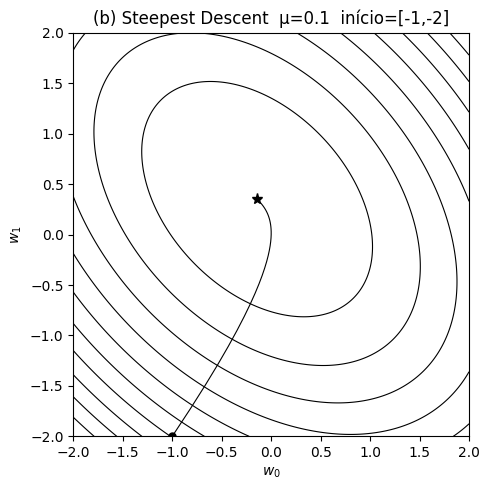

In [31]:
# (b) Steepest Descent — μ pequeno, inicio em [-1, -2]
w = np.array([-1.0, -2.0])
lr = 0.1
traj_sd = [w.copy()]

for _ in range(100):
    grad = R @ w - p
    w = w - lr * grad
    traj_sd.append(w.copy())

traj_sd = np.array(traj_sd)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contour(W0, W1, Z, levels=levels, colors="black", linewidths=0.8)
ax.plot(traj_sd[:, 0], traj_sd[:, 1], "k-", linewidth=0.8)
ax.plot(traj_sd[0, 0], traj_sd[0, 1], "ko", markersize=5)  # início
ax.plot(traj_sd[-1, 0], traj_sd[-1, 1], "k*", markersize=8)  # fim
ax.invert_yaxis()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_1$")
ax.set_title(f"(b) Steepest Descent  μ={lr}  início=[-1,-2]")
plt.tight_layout()


print(f"\n(b) Steepest Descent convergiu para: w = {traj_sd[-1]}")
plt.show()

# 
1c


(c) Newton convergiu para: w = [-0.14213944  0.3513954 ]
    Solução exata  R⁻¹p  = [-0.14213944  0.3513954 ]


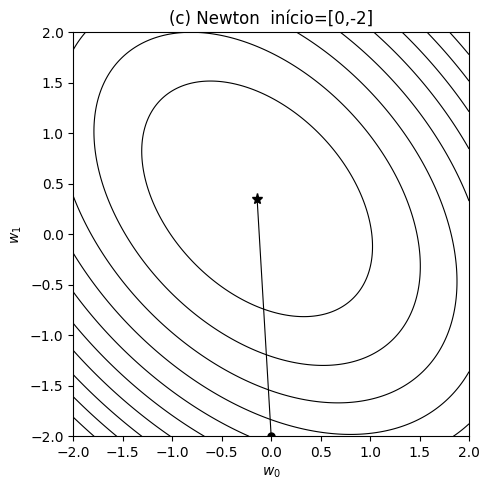

In [ ]:
# (c) Newton — inicio em [0, -2]

# Para MSE quadrático o Hessiano é exatamente R,
# então Newton converge em 1 passo: w = R⁻¹ p
w = np.array([0.0, -2.0])
traj_nt = [w.copy()]

for _ in range(10):
    grad = R @ w - p
    H = R  # Hessiano = R (constante)
    w = w - np.linalg.solve(H, grad)
    traj_nt.append(w.copy())

traj_nt = np.array(traj_nt)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contour(W0, W1, Z, levels=levels, colors="black", linewidths=0.8)
ax.plot(traj_nt[:, 0], traj_nt[:, 1], "k-", linewidth=0.8)
ax.plot(traj_nt[0, 0], traj_nt[0, 1], "ko", markersize=5)
ax.plot(traj_nt[-1, 0], traj_nt[-1, 1], "k*", markersize=8)
ax.invert_yaxis()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_1$")
ax.set_title("(c) Newton  início=[0,-2]")
plt.tight_layout()

w_opt = np.linalg.solve(R, p)
print(f"\n(c) Newton convergiu para: w = {traj_nt[-1]}")
print(f"    Solução exata  R⁻¹p  = {w_opt}")
plt.show()